# Predição de Preços de Aluguél Airbnb - Rio

## 1 - Entendimento do Negócio

Um investidor possui um imóvel no Rio de Janeiro e quer saber qual é a faixa de preço praticada pelo mercado para imóveis com características semelhantes (localização, tipo de acomodação, capacidade, comodidades, reputação do anfitrião) — para não precificar nem muito abaixo (perdendo receita) nem muito acima (perdendo competitividade e ocupação) do que o mercado já pratica.

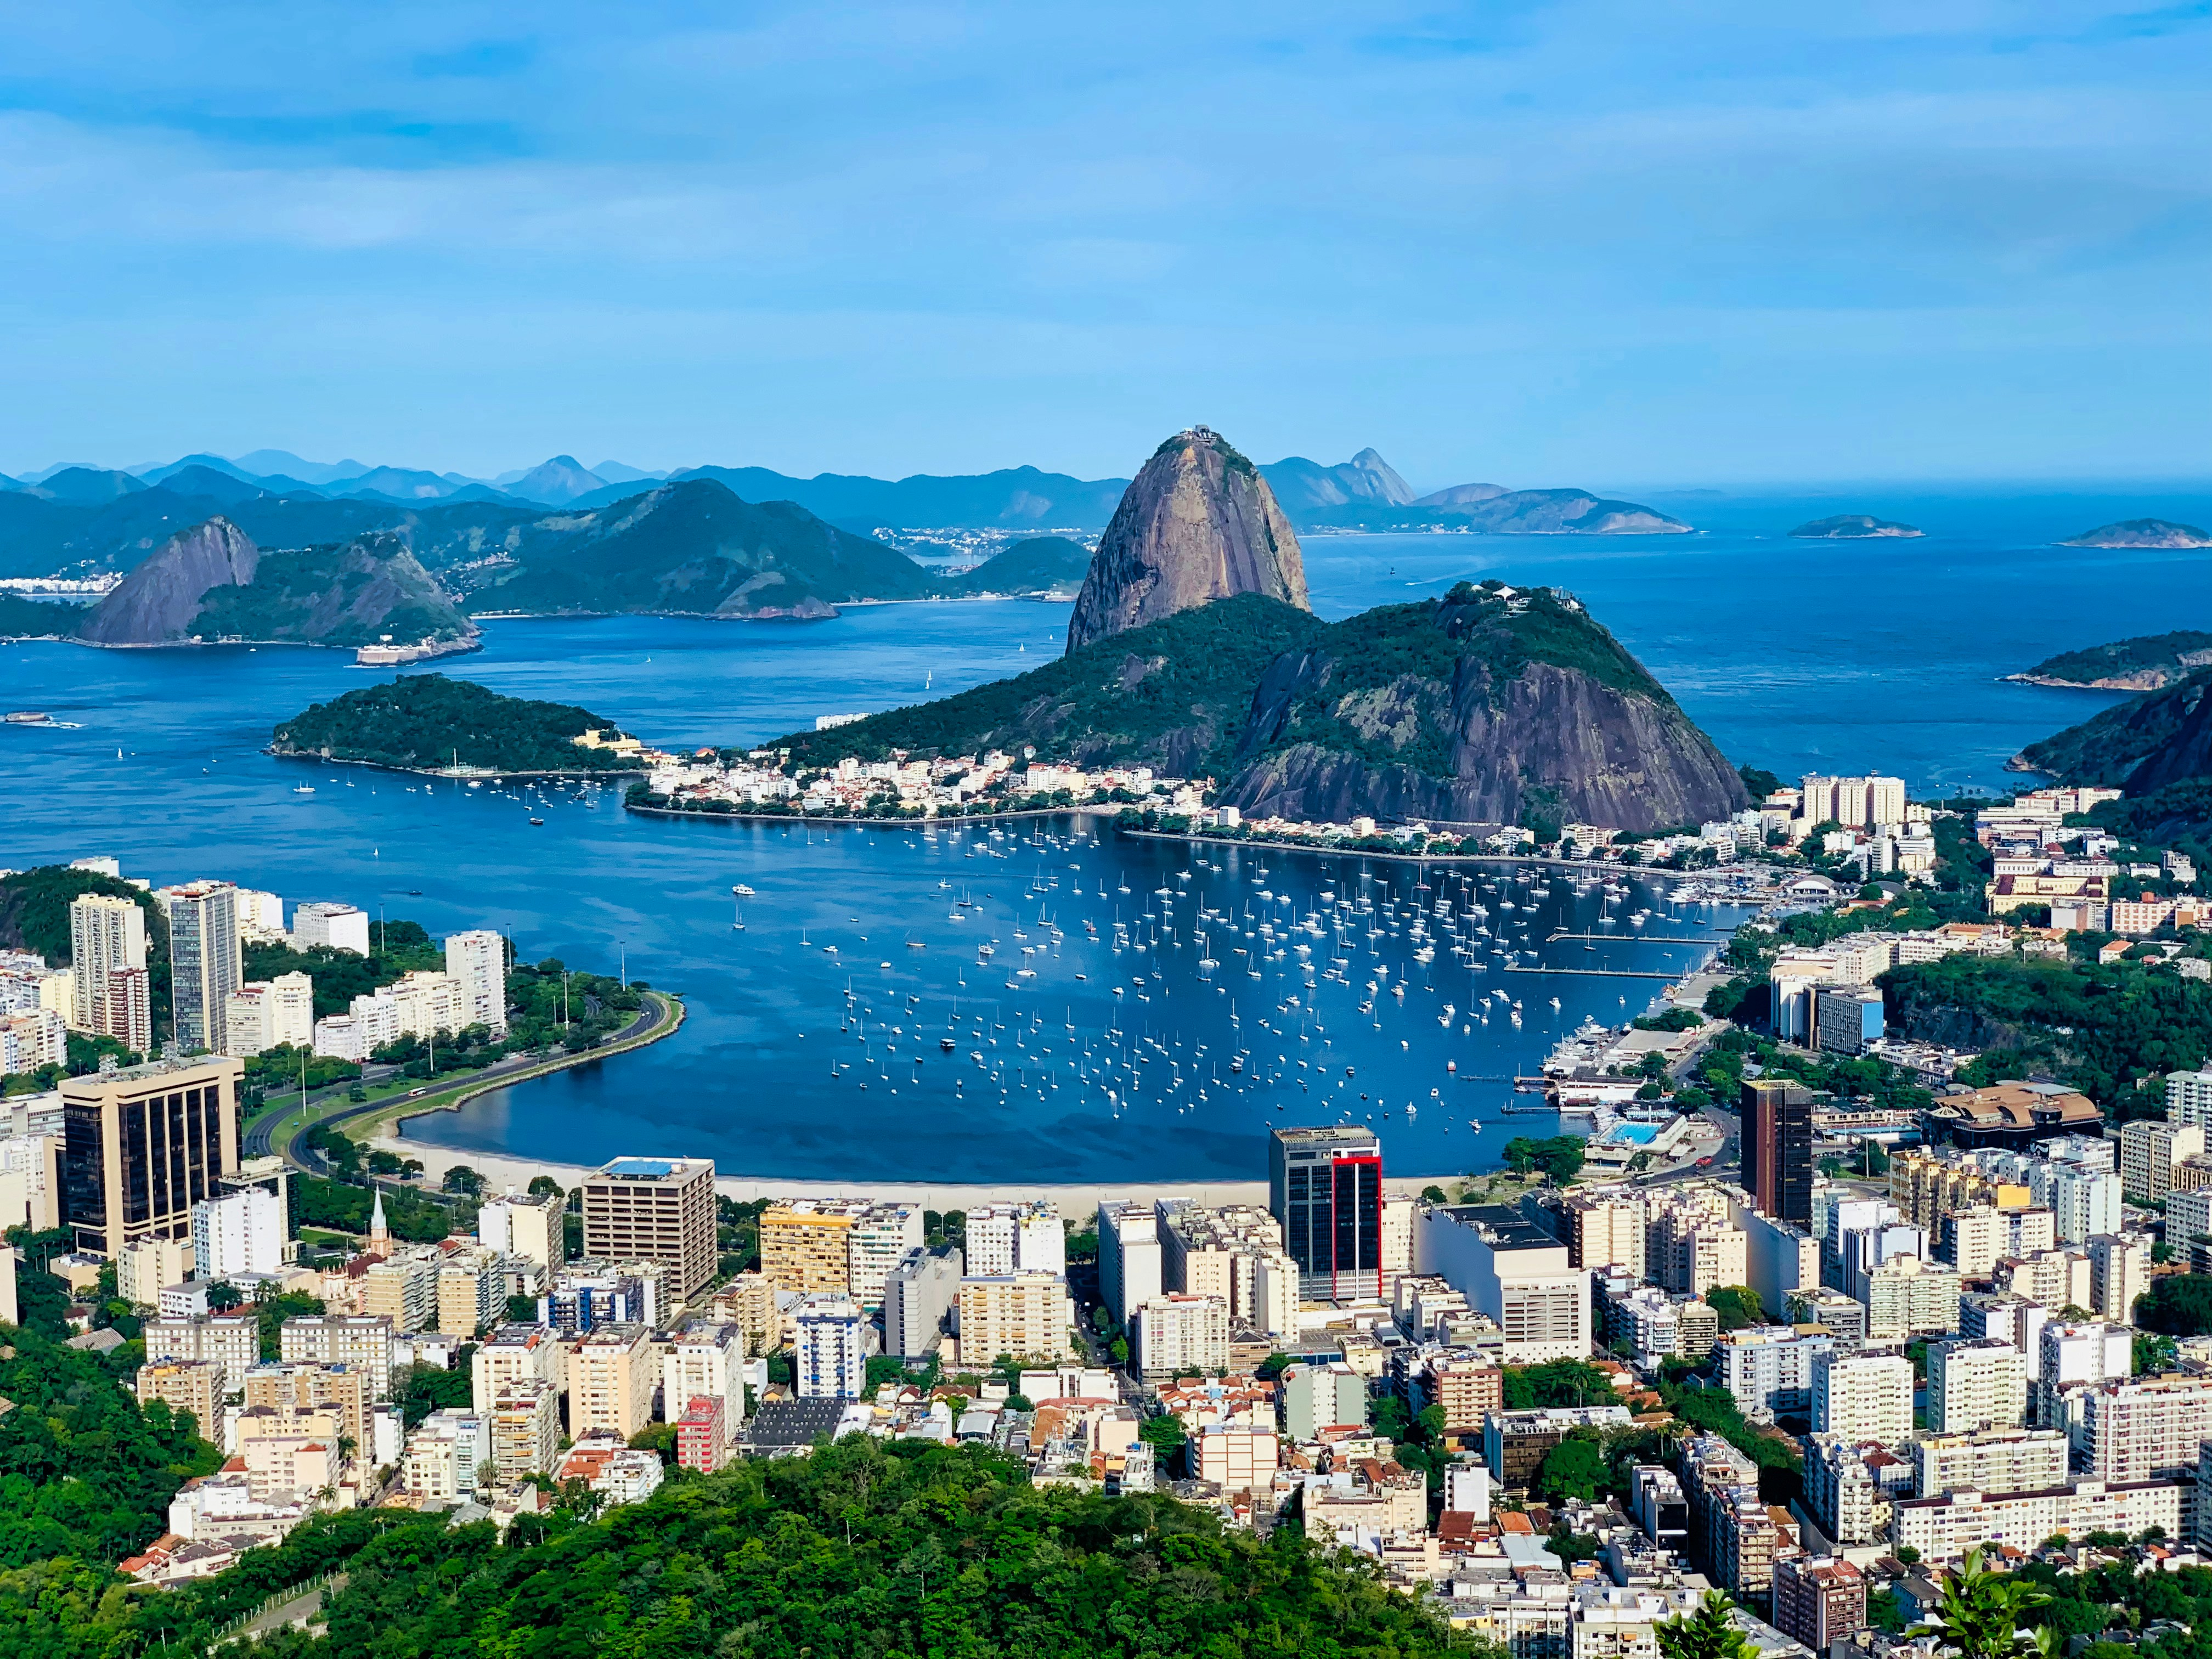
Foto de Davi Costa via Unsplash: https://unsplash.com/pt-br/s/fotografias/rio-de-janeiro - Uso gratuito sob a Licença da Unsplash

Fonte:

https://insideairbnb.com/pt/get-the-data/

listings.csv.gz -	Detailed Listings data

Rio de Janeiro
Data - 24 June, 2026

## 2 - Entendimento dos Dados

### 2.1 - Importações e carga

In [1]:
# Imports
import joblib
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# carga
dados = pd.read_csv('./data/listings.csv', encoding='utf-8')


In [3]:
dados.shape

(48713, 90)

In [4]:
dados.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 90, dtype: object

In [5]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [6]:
dados.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [7]:
dados.isnull().sum().sort_values(ascending = False)

neighborhood_overview                           48713
host_since                                      48713
host_response_time                              48713
host_thumbnail_url                              48713
host_acceptance_rate                            48713
                                                ...  
availability_30                                     0
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
Length: 90, dtype: int64

In [8]:
# amostra
# dados.sample(5)

In [9]:
print(dados['price'])

0              NaN
1          $219.11
2        $1,659.27
3          $704.00
4          $575.24
           ...    
48708    $1,249.59
48709    $7,120.94
48710          NaN
48711      $160.00
48712    $1,484.00
Name: price, Length: 48713, dtype: str


## 3 - Análise, Limpeza e Preparação dos dados

### 3.1 - Análise Exploratória

In [10]:
dados.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.871300e+04,4.871300e+04,0.0,4.871300e+04,4.871200e+04,0.0,48712.000000,48712.000000,48711.000000,48711.000000,...,38889.000000,38889.000000,38888.000000,0.0,0.0,48713.000000,48713.000000,48713.000000,48713.000000,38890.000000
mean,1.003459e+18,2.026062e+13,NaN,1.053919e+16,1.480948e+18,NaN,7.045944,5.498542,4.993328,5.311901,...,4.880676,4.855876,4.733233,NaN,NaN,10.348716,9.440416,0.733603,0.169216,1.311476
std,6.131486e+17,0.000000e+00,NaN,1.327813e+17,4.419937e+16,NaN,4.080288,3.336530,4.267274,3.188354,...,0.320955,0.312643,0.412239,NaN,NaN,23.500360,23.395512,2.074784,1.744723,1.366291
min,1.787800e+04,2.026062e+13,NaN,3.607000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,6.383977e+17,2.026062e+13,NaN,4.687069e+07,1.463038e+18,NaN,3.000000,3.000000,1.000000,3.000000,...,4.880000,4.830000,4.670000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.270000
50%,1.232781e+18,2.026062e+13,NaN,1.941191e+08,1.467126e+18,NaN,8.000000,5.000000,4.000000,5.000000,...,4.980000,4.950000,4.830000,NaN,NaN,2.000000,1.000000,0.000000,0.000000,0.880000
75%,1.536960e+18,2.026062e+13,NaN,4.753410e+08,1.470232e+18,NaN,10.000000,8.000000,9.000000,8.000000,...,5.000000,5.000000,5.000000,NaN,NaN,7.000000,5.000000,1.000000,0.000000,1.950000
max,1.714893e+18,2.026062e+13,NaN,1.714514e+18,1.716070e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,NaN,NaN,169.000000,169.000000,22.000000,39.000000,26.690000


In [11]:
# o ID está na URL do anúncio: 1469168565366316043

dados[dados['listing_url'].str.contains('1469168565366316043', na=False)][['id', 'name', 'price']]

,id,name,price
6125,1469168565366316043,Studio Incrível e vistão da Enseada Baía Guana...,$496.03


In [12]:
# 1. limpar price: remover "$" e "," e converter para float
dados['price'] = (
    dados['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [13]:
# 2. describe só da coluna price
dados['price'].describe()

count     44542.000000
mean        877.707421
std        4599.612177
min           5.540000
25%         296.710000
50%         452.670000
75%         761.537500
max      574013.000000
Name: price, dtype: float64

#### 3.1.1 - Análise dos bairros e preços

In [14]:
# olhar os 15 preços mais altos com contexto
dados.nlargest(15, 'price')[['name', 'room_type', 'price', 'minimum_nights', 'accommodates', 'neighbourhood_cleansed']]

,name,room_type,price,minimum_nights,accommodates,neighbourhood_cleansed
19734,Pede Desconto Copacabana Top Piso em Mármore,Entire home/apt,574013.00,1.0,4,Copacabana
27039,Apartamento em Rio de Janeiro,Entire home/apt,570726.00,1.0,4,Estácio
33701,Quarto em Apartamento vila do chaves,Private room,183602.00,1.0,3,Itanhangá
19912,Varandas Mar Copacabana + Seguro +Claro +Amplo,Entire home/apt,179279.00,1.0,10,Copacabana
19678,Vista Lateral Mar +4 Varandinhas +Melhor Endereço,Entire home/apt,114118.00,1.0,10,Copacabana
24283,Apartamento copacabana posto 2,Entire home/apt,114117.71,6.0,6,Copacabana
19873,Maior & Mais Central & Mais Econômico,Entire home/apt,91293.25,1.0,6,Copacabana
19684,Gigante Melhor Localização de Copacabana,Entire home/apt,80796.00,1.0,6,Copacabana
25310,Apto 1Q no Melhor Ponto de Copacabana (Posto 4),Entire home/apt,80011.82,2.0,2,Copacabana
3595,Casas de Famosos para Locação na Barra da Tijuca,Private room,69498.00,1.0,16,Barra da Tijuca


In [15]:
# olhar os 15 preços mais baixos com contexto
dados.nsmallest(15, 'price')[['name', 'room_type', 'price', 'minimum_nights', 'accommodates', 'neighbourhood_cleansed']]

,name,room_type,price,minimum_nights,accommodates,neighbourhood_cleansed
47998,Quarto da vó Vina na Vila da Penha,Private room,5.54,120.0,2,Vicente de Carvalho
7620,Apartamento mobiliado próximo ao Park shopping,Entire home/apt,6.19,365.0,5,Campo Grande
48005,Casa 2 quartos à 50min de Capacabana RJ,Entire home/apt,14.25,90.0,6,Vicente de Carvalho
35945,República Femenina Lírios do Vale,Entire home/apt,14.34,120.0,2,Jardim Carioca
29097,Kitnet com entrada independente.,Entire home/apt,16.51,180.0,1,Grajaú
40566,Apartamento 2 Quartos Mirataia,Entire home/apt,17.24,364.0,4,Pechincha
11838,Studio Copacabana posto 6 somente Mensal,Entire home/apt,20.71,360.0,2,Copacabana
34472,"Barra da Tijuca, apto com vista privilegiada",Private room,22.09,180.0,2,Jacarepaguá
27381,Quarto no Flamengo,Private room,22.12,120.0,2,Flamengo
25644,Maravilhoso sala é quarto.,Entire home/apt,24.03,365.0,2,Copacabana


In [16]:
dados['minimum_nights'].describe()


count    48706.000000
mean         3.139264
std         13.706673
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        730.000000
Name: minimum_nights, dtype: float64

In [17]:
ocupacao_media = dados['estimated_occupancy_l365d'].mean()
print(f"Ocupação média: {ocupacao_media:.1f} dias/ano")
print(f"Isso representa {ocupacao_media/365*100:.1f}% do ano")

Ocupação média: 55.2 dias/ano
Isso representa 15.1% do ano


In [18]:
# calcular a vacância (o inverso)
dados['vacancia_dias'] = 365 - dados['estimated_occupancy_l365d']
vacancia_media = dados['vacancia_dias'].mean()
print(f"Vacância média: {vacancia_media:.1f} dias/ano ({vacancia_media/365*100:.1f}% do ano)")

Vacância média: 309.8 dias/ano (84.9% do ano)


Ocupação e vacância nos top15 bairros:

In [19]:
resultado = dados.groupby('neighbourhood_cleansed').agg(
    ocupacao_media=('estimated_occupancy_l365d', 'mean'),
    qtd_imoveis=('estimated_occupancy_l365d', 'count')
).sort_values('qtd_imoveis', ascending=False).head(15)

resultado['vacancia_media'] = 365 - resultado['ocupacao_media']
resultado['ocupacao_pct'] = resultado['ocupacao_media'] / 365 * 100
print(resultado)

                          ocupacao_media  qtd_imoveis  vacancia_media  \
neighbourhood_cleansed                                                  
Copacabana                     68.853884        15036      296.146116   
Ipanema                        72.903768         3928      292.096232   
Barra da Tijuca                48.949189         3759      316.050811   
Centro                         65.636722         3295      299.363278   
Recreio dos Bandeirantes       33.968510         2477      331.031490   
Botafogo                       59.840822         2092      305.159178   
Leblon                         71.041310         1985      293.958690   
Jacarepaguá                    31.415690         1963      333.584310   
Santa Teresa                   37.415083         1737      327.584917   
Flamengo                       56.547481         1032      308.452519   
Leme                           54.333692          929      310.666308   
Camorim                        62.954644          9

In [20]:
dados.shape

(48713, 91)

Rodar novamente após a limpeza e filtro de negócio

### 3.2 - Data Cleaning & Data Wrangling

#### 3.2.1 - Limpeza de dados ausentes

In [21]:
dados.isnull().sum()

id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                             0
                                                ... 
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                               9823
vacancia_dias                                      0
Length: 91, dtype: int64

In [22]:
dados.isnull().sum().sort_values(ascending = False)

neighborhood_overview                           48713
host_thumbnail_url                              48713
host_since                                      48713
host_response_rate                              48713
host_response_time                              48713
                                                ...  
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
vacancia_dias                                       0
Length: 91, dtype: int64

In [23]:
with pd.option_context('display.max_rows', None):
    print(dados.isnull().sum().sort_values(ascending=False))

neighborhood_overview                           48713
host_thumbnail_url                              48713
host_since                                      48713
host_response_rate                              48713
host_response_time                              48713
host_acceptance_rate                            48713
neighbourhood_group_cleansed                    48713
neighbourhood                                   48713
host_verifications                              48713
host_total_listings_count                       48713
host_neighbourhood                              48713
calendar_updated                                48713
instant_bookable                                48713
license                                         48713
host_about                                      24878
host_location                                   11120
review_scores_value                              9825
review_scores_location                           9824
review_scores_communication 

In [24]:
dados.shape

(48713, 91)

In [25]:
# Extraindo o total de valores ausentes por coluna
valores_ausentes = dados.isnull().sum().sort_values(ascending = False)

In [26]:
print(valores_ausentes)

neighborhood_overview                           48713
host_thumbnail_url                              48713
host_since                                      48713
host_response_rate                              48713
host_response_time                              48713
                                                ...  
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
vacancia_dias                                       0
Length: 91, dtype: int64


In [27]:
# Calculando o percentual de valores ausentes
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / dados.shape[0] 

In [28]:
print(f'{valores_ausentes_percent * 100} %')

neighborhood_overview           100.000000
host_thumbnail_url              100.000000
host_since                      100.000000
host_response_rate              100.000000
host_response_time              100.000000
host_acceptance_rate            100.000000
neighbourhood_group_cleansed    100.000000
neighbourhood                   100.000000
host_verifications              100.000000
host_total_listings_count       100.000000
host_neighbourhood              100.000000
calendar_updated                100.000000
instant_bookable                100.000000
license                         100.000000
host_about                       51.070556
host_location                    22.827582
review_scores_value              20.169154
review_scores_location           20.167101
review_scores_communication      20.167101
review_scores_accuracy           20.167101
review_scores_cleanliness        20.165048
last_review                      20.165048
first_review                     20.165048
review_scor

In [29]:
# Excluindo colunas 100% ausentes
colunas_100_ausentes = valores_ausentes[valores_ausentes == dados.shape[0]].index
dados = dados.drop(columns=colunas_100_ausentes)

In [30]:
# Excluindo a coluna host_about com o método drop
dados.drop("host_about", axis = 1, inplace = True)

# host_location Categórica, alta cardinalidade, provavelmente pouco relevante pra prever preço
dados = dados.drop(columns=['host_location'])

#review_score_rating vai ser devolvida ao dataframe
dados = dados.drop(columns=['review_scores_value', 'review_scores_location', 'review_scores_accuracy',
                            'review_scores_communication','review_scores_checkin',
                            'review_scores_cleanliness','reviews_per_month'
                            ]) 

# bathrooms, bedrooms, beds (10-15%)
# Essas são características físicas do imóvel — muito relevantes para prever preço.
# preencher com a mediana review_score_rating
for col in ['bathrooms', 'bedrooms', 'beds']:
    dados[col] = dados[col].fillna(dados[col].median())

In [32]:
dados['review_scores_rating'] = dados['review_scores_rating'].fillna(dados['review_scores_rating'].median())

In [33]:
# price é sua variável-alvo (y), remova as linhas onde ela é nula — não impute o alvo:
dados = dados.dropna(subset=['price'])

In [34]:
# 2% abaixo te, Percentual pequeno — dropna nas linhas é seguro e não compromete o volume de dados
dados = dados.dropna(subset=['description', 'has_availability', 'bathrooms_text',
                              'maximum_nights', 'minimum_maximum_nights', 'minimum_minimum_nights',
                              'maximum_minimum_nights', 'minimum_nights', 'maximum_maximum_nights',
                              'hosts_time_as_host_years', 'hosts_time_as_host_months',
                              'host_identity_verified', 'host_listings_count', 'host_picture_url',
                              'hosts_time_as_user_years', 'host_is_superhost', 'host_profile_id',
                              'host_name', 'hosts_time_as_user_months', 'host_profile_url',
                              'host_has_profile_pic'])

In [ ]:
# Ver o dataframe
# dados.sample(5)

In [35]:
dados = dados.drop(columns=['listing_url', 'id', 'scrape_id',
                            'last_scraped','source','picture_url',
                            'host_url'
                            ])

In [36]:
# IDs, URLs ou textos livres. Não têm valor preditivo direto num modelo de regressão
dados = dados.drop(columns=['host_id', 'host_profile_id', 'host_profile_url',
                             'host_picture_url', 'host_name', 'name', 'description'])

#Redundâncias dentro do próprio price
dados = dados.drop(columns=['price_quote_checkin_date', 'price_quote_checkout_date',
                             'price_quote_total_price', 'price_quote_price_per_night',
                             'price_quote_raw'])

# Redundância entre bathrooms e bathrooms_text
dados = dados.drop(columns=['bathrooms_text'])

# manter só minimum_nights e maximum_nights - isso é excesso de multicolinearidade
dados = dados.drop(columns=['minimum_minimum_nights', 'maximum_minimum_nights',
                             'minimum_maximum_nights', 'maximum_maximum_nights',
                             'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'])

# Calendário calendar_last_scraped metadado do processo de coleta
dados = dados.drop(columns=['calendar_last_scraped'])

In [37]:
# Verificar se é booleana
dados['has_availability'].value_counts()

has_availability
t    43309
f      391
Name: count, dtype: int64

In [38]:
# Regra geral aqui: quando uma coluna categórica/booleana tem mais de ~98-99% concentrado em um único valor,
# ela carrega pouca informação discriminativa
dados = dados.drop(columns=['has_availability'])

dados = dados.drop(columns=['hosts_time_as_user_years', 'hosts_time_as_host_years'])

In [39]:
# Verificar se host_is_superhost é booleana
dados['host_is_superhost'].value_counts()

host_is_superhost
f    27600
t    16100
Name: count, dtype: int64

In [40]:
dados = dados.drop(columns=['host_is_superhost'])

In [41]:
dados['host_has_profile_pic'].value_counts()


host_has_profile_pic
t    41856
f     1844
Name: count, dtype: int64

In [42]:
dados = dados.drop(columns=['host_identity_verified'])
dados = dados.drop(columns=['host_has_profile_pic'])

# 4 colunas quase redundantes
# explicam a mesma coisa que availability_365
dados = dados.drop(columns=['availability_30', 
                            'availability_60', 'availability_90', 'availability_eoy'
                            ])

# number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, number_of_reviews_ly — mesmo padrão
# tirar redundancia de number_of_reviews
dados = dados.drop(columns=['number_of_reviews_ltm', 
                            'number_of_reviews_l30d', 'number_of_reviews_ly'])

# calculated_host_listings_count + as 3 quebras (entire homes / private rooms / shared rooms)
#As três quebras somadas tendem a bater com o total

dados = dados.drop(columns=['calculated_host_listings_count_entire_homes',
                             'calculated_host_listings_count_private_rooms',
                             'calculated_host_listings_count_shared_rooms'])

In [43]:
dados.isnull().sum().sort_values(ascending = False)

last_review                       8599
first_review                      8599
host_listings_count                  0
hosts_time_as_host_months            0
latitude                             0
longitude                            0
property_type                        0
neighbourhood_cleansed               0
hosts_time_as_user_months            0
accommodates                         0
room_type                            0
bathrooms                            0
bedrooms                             0
price                                0
minimum_nights                       0
beds                                 0
amenities                            0
availability_365                     0
maximum_nights                       0
estimated_occupancy_l365d            0
number_of_reviews                    0
estimated_revenue_l365d              0
review_scores_rating                 0
calculated_host_listings_count       0
vacancia_dias                        0
dtype: int64

In [44]:
dados[['first_review', 'last_review']].dtypes
dados[['first_review', 'last_review']].head()

,first_review,last_review
1,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,2025-08-19,2026-05-06
6,NaN,NaN


In [45]:
dados = dados.drop(columns=['first_review', 'last_review'])

In [46]:
dados[[

    "estimated_occupancy_l365d",
    "neighbourhood_cleansed", 
    "latitude", 'longitude'
]].tail()


,estimated_occupancy_l365d,neighbourhood_cleansed,latitude,longitude
48707,6,Vila Valqueire,-22.887040,-43.365270
48708,0,Vila Valqueire,-22.895420,-43.367298
48709,0,Vila Valqueire,-22.890290,-43.362983
48711,0,Zumbi,-22.821114,-43.174663
48712,0,Zumbi,-22.820690,-43.175270


In [47]:
# Atenção: estimated_revenue_l365d — risco de vazamento de dados
# Receita estimada geralmente é calculada como algo como price × ocupação estimada
# Se a correlação com price for muito alta (>0.9) e a fórmula bater, eu dropraria:
dados[['price', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']].corr()

,price,estimated_occupancy_l365d,estimated_revenue_l365d
price,1.000000,-0.058848,0.089049
estimated_occupancy_l365d,-0.058848,1.000000,0.485858
estimated_revenue_l365d,0.089049,0.485858,1.000000


Baixa correlação: não há sinal de vazamento.
Mas por segurança, vamos dropar


In [48]:
# drop na variavel estimated_revenue_l365d
dados = dados.drop(columns=['estimated_revenue_l365d'])

In [49]:
dados.info()

<class 'pandas.DataFrame'>
Index: 43700 entries, 1 to 48712
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hosts_time_as_user_months       43700 non-null  float64
 1   hosts_time_as_host_months       43700 non-null  float64
 2   host_listings_count             43700 non-null  float64
 3   neighbourhood_cleansed          43700 non-null  str    
 4   latitude                        43700 non-null  float64
 5   longitude                       43700 non-null  float64
 6   property_type                   43700 non-null  str    
 7   room_type                       43700 non-null  str    
 8   accommodates                    43700 non-null  int64  
 9   bathrooms                       43700 non-null  float64
 10  bedrooms                        43700 non-null  float64
 11  beds                            43700 non-null  float64
 12  amenities                       43700 non-null  

In [50]:
dados.describe()

,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,estimated_occupancy_l365d,review_scores_rating,calculated_host_listings_count,vacancia_dias
count,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000,43700.000000
mean,5.510892,5.299062,14.537391,-22.963932,-43.246699,3.943364,1.417609,1.512105,2.333043,870.196552,2.760870,445.348810,212.637780,29.238124,58.202723,4.828397,10.482654,306.797277
std,3.333633,3.197707,50.023320,0.037188,0.101371,2.279618,0.899687,0.958301,1.903366,4607.185380,9.239174,410.616308,117.293917,51.975336,74.614494,0.342717,23.879832,74.614494
min,0.000000,0.000000,0.000000,-23.072920,-43.710850,1.000000,0.500000,0.000000,1.000000,5.540000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,110.000000
25%,3.000000,3.000000,1.000000,-22.984182,-43.275701,2.000000,1.000000,1.000000,1.000000,296.710000,1.000000,90.000000,94.000000,1.000000,0.000000,4.820000,1.000000,269.000000
50%,5.000000,5.000000,2.000000,-22.970354,-43.192880,4.000000,1.000000,1.000000,2.000000,451.145000,2.000000,365.000000,207.000000,9.000000,24.000000,4.920000,2.000000,341.000000
75%,8.000000,8.000000,8.000000,-22.944997,-43.183754,5.000000,2.000000,2.000000,3.000000,759.000000,3.000000,730.000000,340.000000,35.000000,96.000000,5.000000,7.000000,365.000000
max,11.000000,11.000000,3104.000000,-22.750510,-43.103600,16.000000,18.000000,27.000000,50.000000,574013.000000,365.000000,1125.000000,365.000000,805.000000,255.000000,5.000000,169.000000,365.000000


### 3.3 - Tratamento de outliers

Antes de tratarmos as variaveis categóricas, vamos analisar os outliers

In [51]:
dados.columns

Index(['hosts_time_as_user_months', 'hosts_time_as_host_months',
       'host_listings_count', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'estimated_occupancy_l365d', 'review_scores_rating',
       'calculated_host_listings_count', 'vacancia_dias'],
      dtype='str')

#### 3.3.1 - Filtro negocial - tratamento de outliers

In [52]:
# Top 15 imóveis com os maiores preços
dados[["neighbourhood_cleansed", "property_type" , "room_type", "price"]].sort_values(by="price", ascending=False).head(15)

,neighbourhood_cleansed,property_type,room_type,price
19734,Copacabana,Entire rental unit,Entire home/apt,574013.00
27039,Estácio,Entire rental unit,Entire home/apt,570726.00
33701,Itanhangá,Private room in rental unit,Private room,183602.00
19912,Copacabana,Entire rental unit,Entire home/apt,179279.00
19678,Copacabana,Entire rental unit,Entire home/apt,114118.00
24283,Copacabana,Entire rental unit,Entire home/apt,114117.71
19873,Copacabana,Entire rental unit,Entire home/apt,91293.25
19684,Copacabana,Entire rental unit,Entire home/apt,80796.00
3595,Barra da Tijuca,Private room in home,Private room,69498.00
23018,Copacabana,Entire rental unit,Entire home/apt,67429.70


In [53]:
# Tirar os imóveis com período minimo de aluguel acima de 30
dados.drop(dados[dados.minimum_nights > 30].index, axis = 0, inplace = True)

Determinar os valores de corte de price

In [54]:
dados['price'].quantile([0.90, 0.95, 0.97, 0.98, 0.99])

0.90    1386.5150
0.95    2282.4000
0.97    3142.2145
0.98    4562.8110
0.99    7417.7415
Name: price, dtype: float64

In [55]:
#3.000 fica bem alinhado com o percentil 97%
dados = dados[dados["price"] <= 3_000]
dados.reset_index(drop=True, inplace=True)

In [56]:
print(dados.shape)

(42131, 22)


findfont: Failed to find font weight semibold, now using 700.


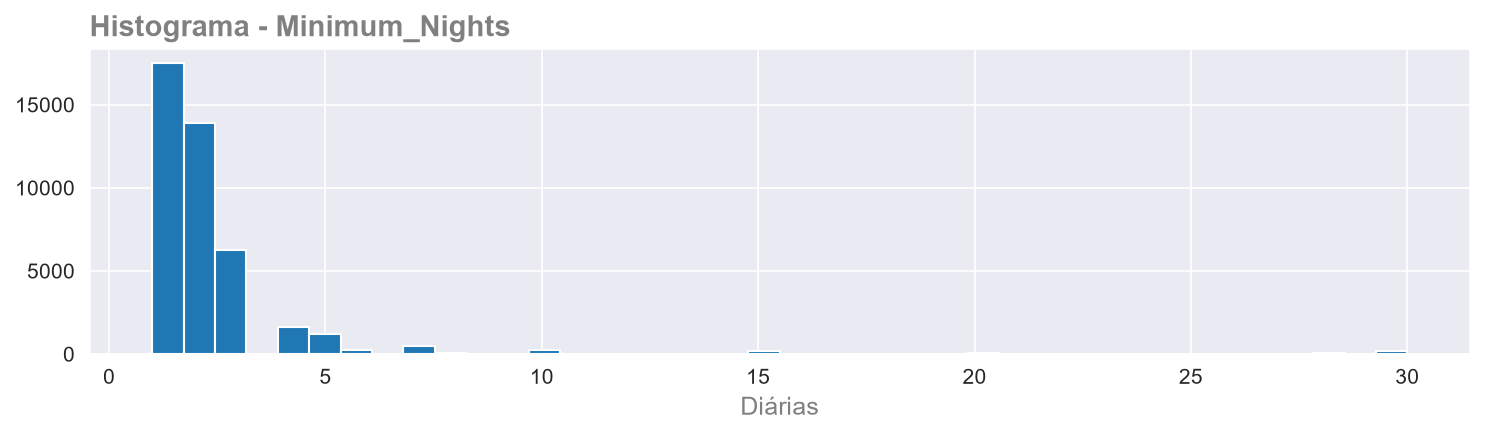

In [57]:
# Plotando um histograma da coluna "minimum_nights" sem "outliers"
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
sns.set_style()
ax.hist("minimum_nights", data = dados, bins = 40) # data = DF que esta sendo usado
ax.set_title("Histograma - Minimum_Nights", color="grey", fontsize=14, fontweight="semibold", loc="left")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()
plt.savefig("Histograma.jpeg")

In [58]:
dados['minimum_nights'].quantile([0.90, 0.95, 0.97, 0.98, 0.99])

0.90     4.0
0.95     5.0
0.97     7.0
0.98    10.0
0.99    15.0
Name: minimum_nights, dtype: float64

98% dos dados estão com 10 dias

99% dos dados estão com 15 diarias minimas

In [59]:
dados = dados[dados["minimum_nights"] <= 10]
dados.reset_index(drop=True, inplace=True)
print(dados.shape)

(41514, 22)


De 42.131 para 41.514, perdeu-se 617 linhas (~1,5%)

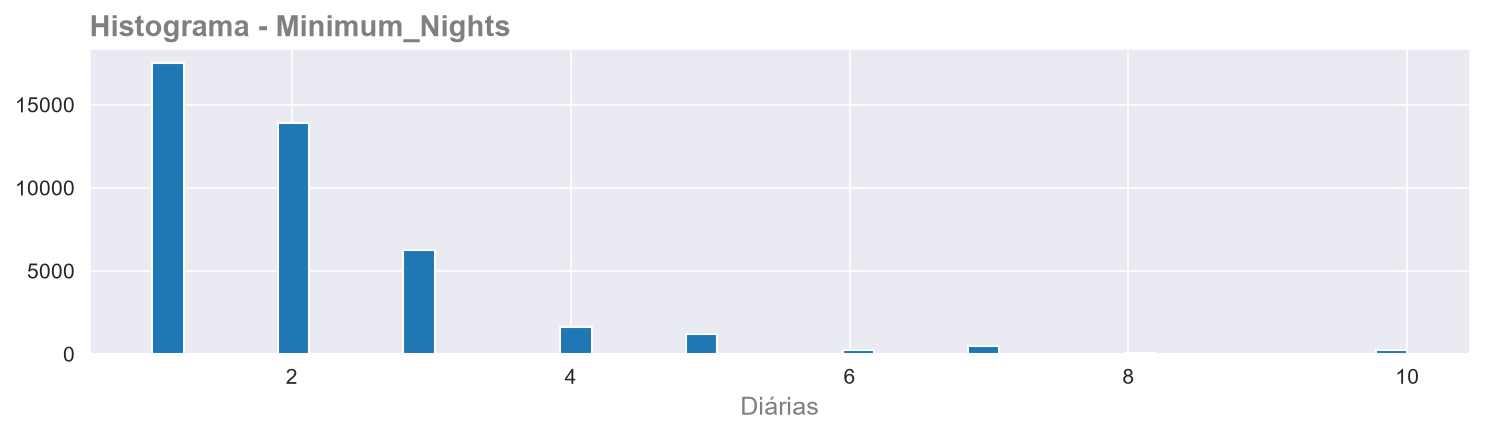

In [60]:
# Plotando um histograma da coluna "minimum_nights" sem "outliers"
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
sns.set_style()
ax.hist("minimum_nights", data = dados, bins = 40) # data = DF que esta sendo usado
ax.set_title("Histograma - Minimum_Nights", color="grey", fontsize=14, fontweight="semibold", loc="left")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()
plt.savefig("Histograma.jpeg")

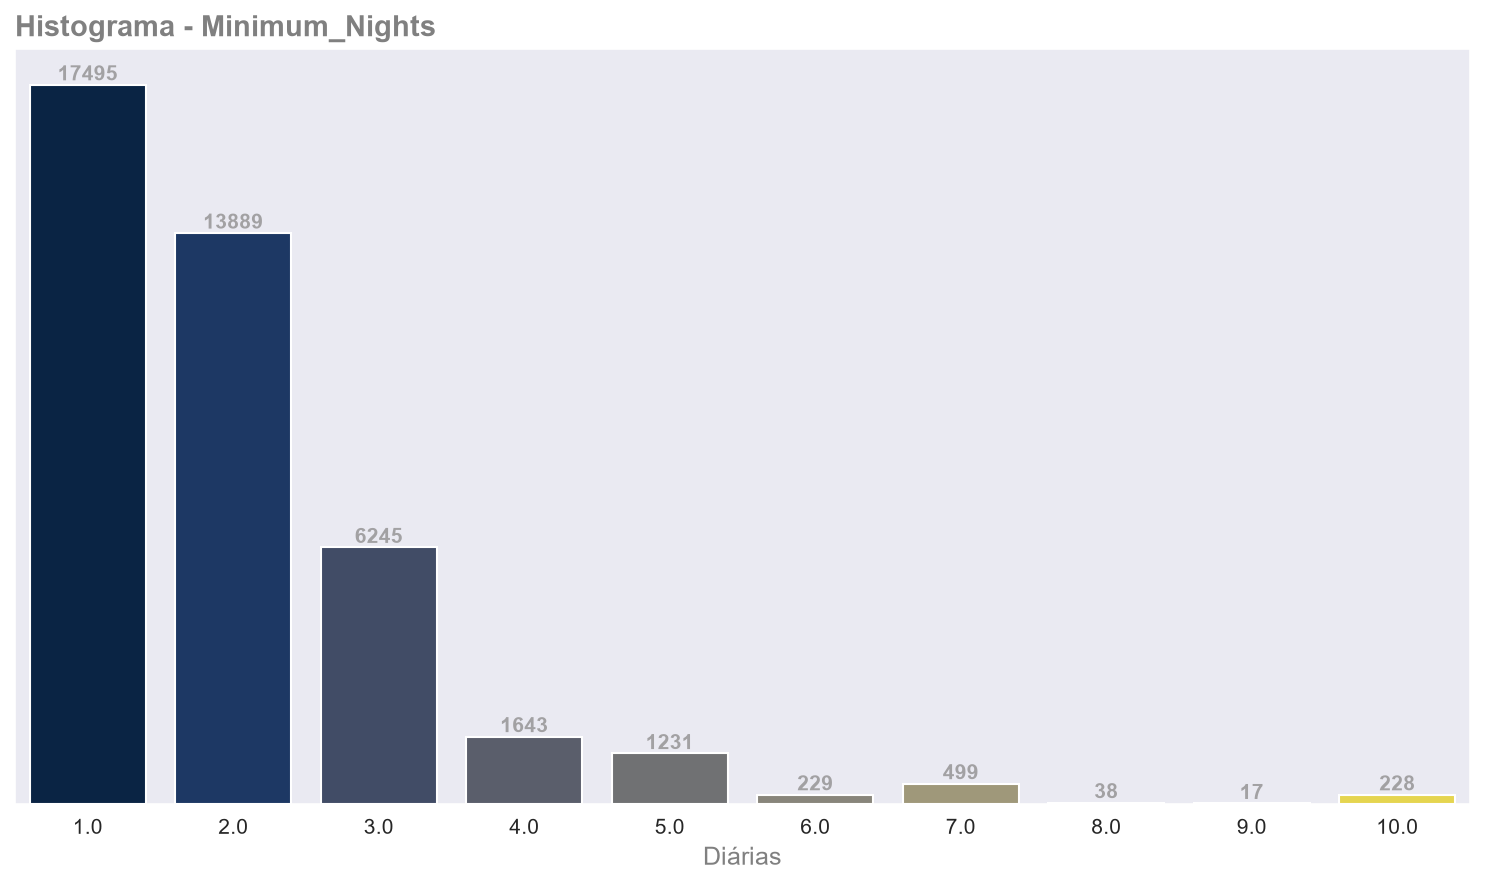

In [98]:
# Countplot com a contagem por dia
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10, 6), dpi = 150)
sns.set_style()

# data = dataframe
barras = sns.countplot(x = "minimum_nights", data = dados, ax = ax, palette = "cividis",
                       hue = "minimum_nights", legend = False)

for i in barras.patches:
  ax.annotate(int(i.get_height()),
              xy = (i.get_x() + i.get_width() / 2,
                    i.get_height()),
              color = "#A2A1A3",
              fontweight = "semibold",
              ha = "center",
              va = "bottom")

plt.gca().axes.get_yaxis().set_visible(False)
ax.set_title("Histograma - Minimum_Nights", color="grey", 
             fontsize=14, fontweight="semibold", loc="left")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("Minimum_Nights.jpeg")

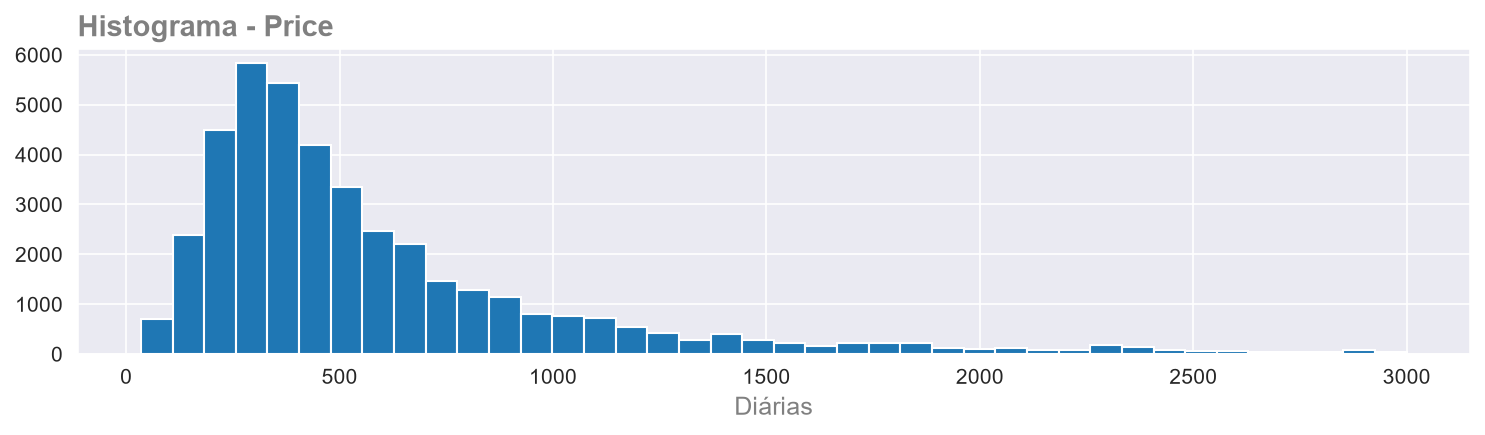

In [62]:
# Plotando um histograma da coluna "price" sem "outliers"
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
sns.set_style()
ax.hist("price", data = dados, bins = 40) # data = DF que esta sendo usado
ax.set_title("Histograma - Price", color="grey", fontsize=14, fontweight="semibold", loc="left")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()
plt.savefig("Histograma_price.jpeg")

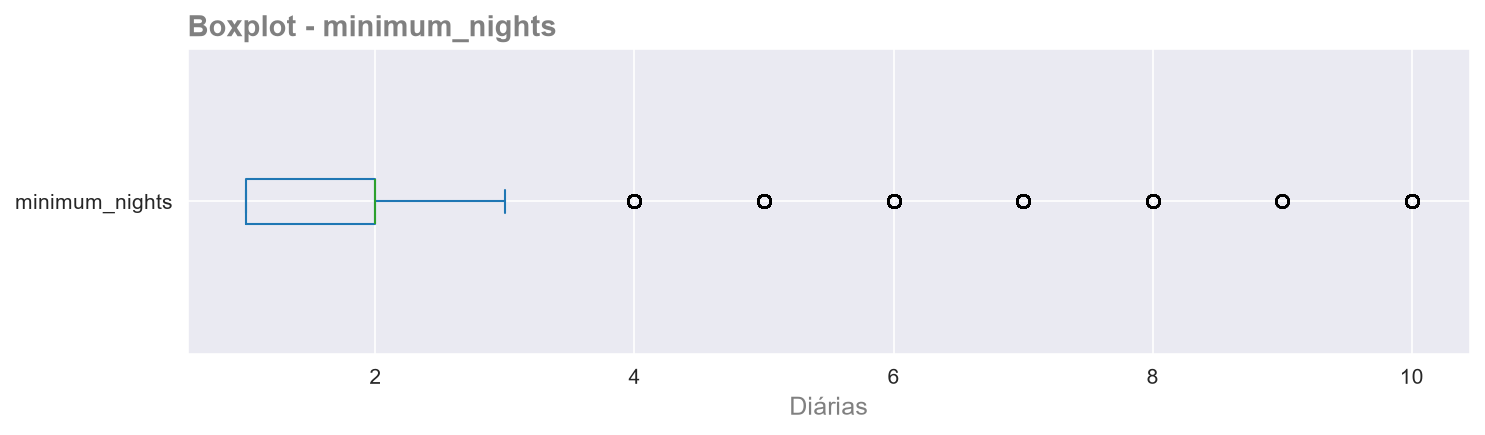

In [63]:
# Boxplot da coluna "minimum_nights" para dados
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
dados.minimum_nights.plot(kind = "box", vert = False, ax = ax)
ax.set_title("Boxplot - minimum_nights", color="grey", fontsize=14, fontweight="semibold", loc="left")
ax.set_ylabel("")
ax.set_xlabel("Diárias", color = "grey", fontsize = 12)
plt.tight_layout()

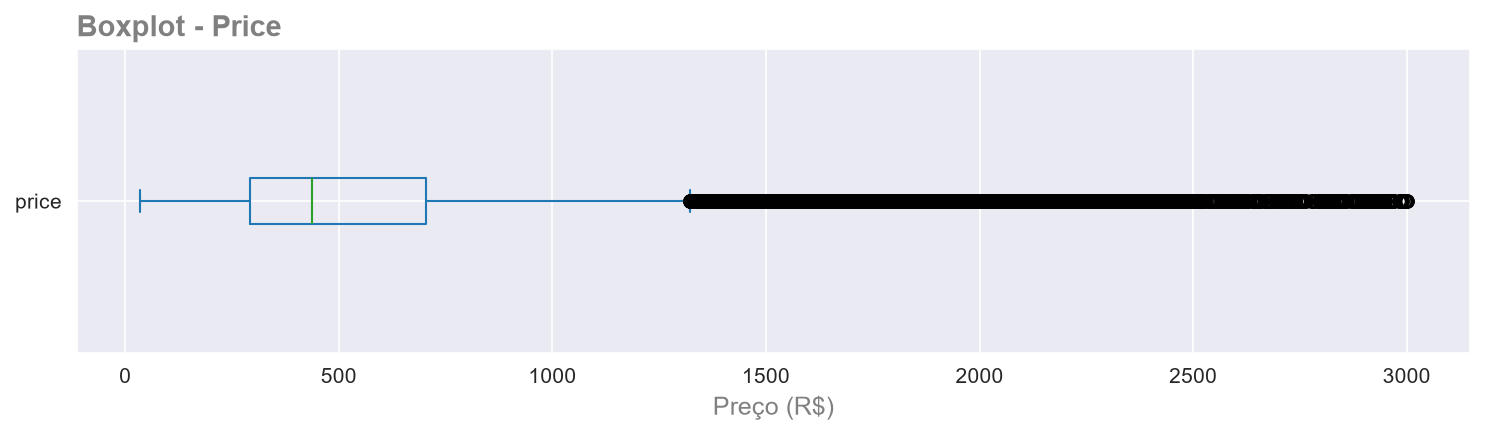

In [64]:
# Boxplot da coluna "minimum_nights" para dados
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize = (10,3), dpi = 150)
dados.price.plot(kind = "box", vert = False, ax = ax)
ax.set_title("Boxplot - Price", color="grey", fontsize=14, fontweight="semibold", loc="left")
ax.set_ylabel("")
ax.set_xlabel("Preço (R$)", color = "grey", fontsize = 12)
plt.tight_layout()

Análise dos boxplots — price e minimum_nights

Os boxplots de price e minimum_nights mostram um grande volume de pontos classificados como "outliers" pelo critério estatístico padrão (1,5× IQR). Isso é esperado em variáveis com distribuição assimétrica à direita, como preço de hospedagem e estadia mínima: a maioria dos valores se concentra numa faixa baixa (a "caixa" do boxplot), enquanto uma cauda longa de valores mais altos, porém menos frequentes, se estende à direita.

Se aplicássemos a regra estatística do boxplot de forma automática, perderíamos uma quantidade excessiva de dados válidos — inclusive imóveis legítimos, apenas mais caros ou com regras de estadia mais longas. Por isso, o tratamento de outliers nesta análise não seguiu o critério do boxplot, e sim uma combinação de percentis e decisão de escopo de negócio: definimos previamente que o foco da análise é o mercado médio de hospedagem, e cortamos price em R$3.000 (≈ percentil 97%) e minimum_nights em 10 noites (≈ percentil 98%), preservando a grande maioria dos dados relevantes e descartando apenas os extremos que fogem do perfil de análise pretendido.

Concluímos, portanto, que os boxplots confirmam a assimetria esperada das variáveis e validam que os cortes já aplicados foram suficientes para o objetivo da análise, sem necessidade de remoção adicional de outliers.

### 3.4 - Informações imobiliarias após os filtros

In [65]:
# olhar os 15 preços mais altos com contexto
dados.nlargest(15, 'price')[['room_type', 'price', 'minimum_nights', 'accommodates', 'neighbourhood_cleansed']]

,room_type,price,minimum_nights,accommodates,neighbourhood_cleansed
3390,Entire home/apt,3000.00,1.0,6,Barra de Guaratiba
37696,Entire home/apt,3000.00,1.0,16,Santa Teresa
26016,Entire home/apt,2997.67,3.0,4,Ipanema
2810,Entire home/apt,2997.00,2.0,6,Barra da Tijuca
35929,Entire home/apt,2996.73,7.0,12,Recreio dos Bandeirantes
17300,Entire home/apt,2995.75,4.0,6,Copacabana
20603,Entire home/apt,2990.00,3.0,6,Copacabana
40783,Entire home/apt,2990.00,3.0,16,Vargem Pequena
18381,Entire home/apt,2986.33,2.0,6,Copacabana
30738,Entire home/apt,2986.33,3.0,8,Jardim Botânico


In [66]:
# olhar os 15 preços mais baixos com contexto
dados.nsmallest(15, 'price')[['room_type', 'price', 'minimum_nights', 'accommodates', 'neighbourhood_cleansed']]


,room_type,price,minimum_nights,accommodates,neighbourhood_cleansed
28919,Shared room,34.51,1.0,4,Itanhangá
28916,Shared room,35.15,1.0,6,Itanhangá
28913,Shared room,35.33,1.0,5,Itanhangá
17569,Private room,41.03,1.0,1,Copacabana
6367,Private room,42.00,1.0,4,Campo Grande
6372,Private room,42.00,1.0,2,Campo Grande
28915,Shared room,43.75,1.0,5,Itanhangá
28930,Shared room,45.65,1.0,1,Jacaré
34551,Shared room,45.65,1.0,1,Penha
3482,Shared room,47.47,1.0,1,Barra de Guaratiba


In [67]:
dados['minimum_nights'].describe()

count    41514.000000
mean         2.031580
std          1.337669
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         10.000000
Name: minimum_nights, dtype: float64

#### 3.4.1 - Ocupação e Vacância

In [68]:
# Ocupacao

ocupacao_media = dados['estimated_occupancy_l365d'].mean()
print(f"Ocupação média: {ocupacao_media:.1f} dias/ano")
print(f"Isso representa {ocupacao_media/365*100:.1f}% do ano")

Ocupação média: 60.1 dias/ano
Isso representa 16.5% do ano


In [69]:
# calcular a vacância (o inverso)
dados['vacancia_dias'] = 365 - dados['estimated_occupancy_l365d']
vacancia_media = dados['vacancia_dias'].mean()
print(f"Vacância média: {vacancia_media:.1f} dias/ano ({vacancia_media/365*100:.1f}% do ano)")


Vacância média: 304.9 dias/ano (83.5% do ano)


In [70]:
#Ocupação e vacância nos top15 bairros:
resultado = dados.groupby('neighbourhood_cleansed').agg(
    ocupacao_media=('estimated_occupancy_l365d', 'mean'),
    qtd_imoveis=('estimated_occupancy_l365d', 'count')
).sort_values('qtd_imoveis', ascending=False).head(15)

resultado['vacancia_media'] = 365 - resultado['ocupacao_media']
resultado['ocupacao_pct'] = resultado['ocupacao_media'] / 365 * 100

print(resultado.head(15))

                          ocupacao_media  qtd_imoveis  vacancia_media  \
neighbourhood_cleansed                                                  
Copacabana                     73.491037        13109      291.508963   
Ipanema                        79.870269         3276      285.129731   
Centro                         68.533955         3004      296.466045   
Barra da Tijuca                56.635066         2943      308.364934   
Recreio dos Bandeirantes       36.852126         2164      328.147874   
Botafogo                       64.847105         1779      300.152895   
Jacarepaguá                    35.682011         1651      329.317989   
Leblon                         79.245062         1620      285.754938   
Santa Teresa                   39.049159         1546      325.950841   
Flamengo                       60.931073          885      304.068927   
Camorim                        68.457772          817      296.542228   
Leme                           57.972257          7

In [72]:
# Vacancia e ocupacao levando-se em conta os números de revies >=4,5
top15_bairros = resultado.index.tolist()

filtro = (
    dados['neighbourhood_cleansed'].isin(top15_bairros) &
    (dados['review_scores_rating'] >= 4.5) &
    (dados['number_of_reviews'] >= 5)
)

resultado_top_avaliados = dados[filtro].groupby('neighbourhood_cleansed').agg(
    ocupacao_media=('estimated_occupancy_l365d', 'mean'),
    qtd_imoveis=('estimated_occupancy_l365d', 'count')
).reindex(top15_bairros)

resultado_top_avaliados['vacancia_media'] = 365 - resultado_top_avaliados['ocupacao_media']
resultado_top_avaliados['ocupacao_pct'] = resultado_top_avaliados['ocupacao_media'] / 365 * 100

print(resultado_top_avaliados.round(1))

                          ocupacao_media  qtd_imoveis  vacancia_media  \
neighbourhood_cleansed                                                  
Copacabana                         108.7         8378           256.3   
Ipanema                            109.5         2286           255.5   
Centro                             108.4         1771           256.6   
Barra da Tijuca                     88.1         1804           276.9   
Recreio dos Bandeirantes            75.4          932           289.6   
Botafogo                            98.1         1097           266.9   
Jacarepaguá                         71.9          779           293.1   
Leblon                             106.5         1152           258.5   
Santa Teresa                        77.4          718           287.6   
Flamengo                            88.2          585           276.8   
Camorim                            107.0          510           258.0   
Leme                                91.4          4

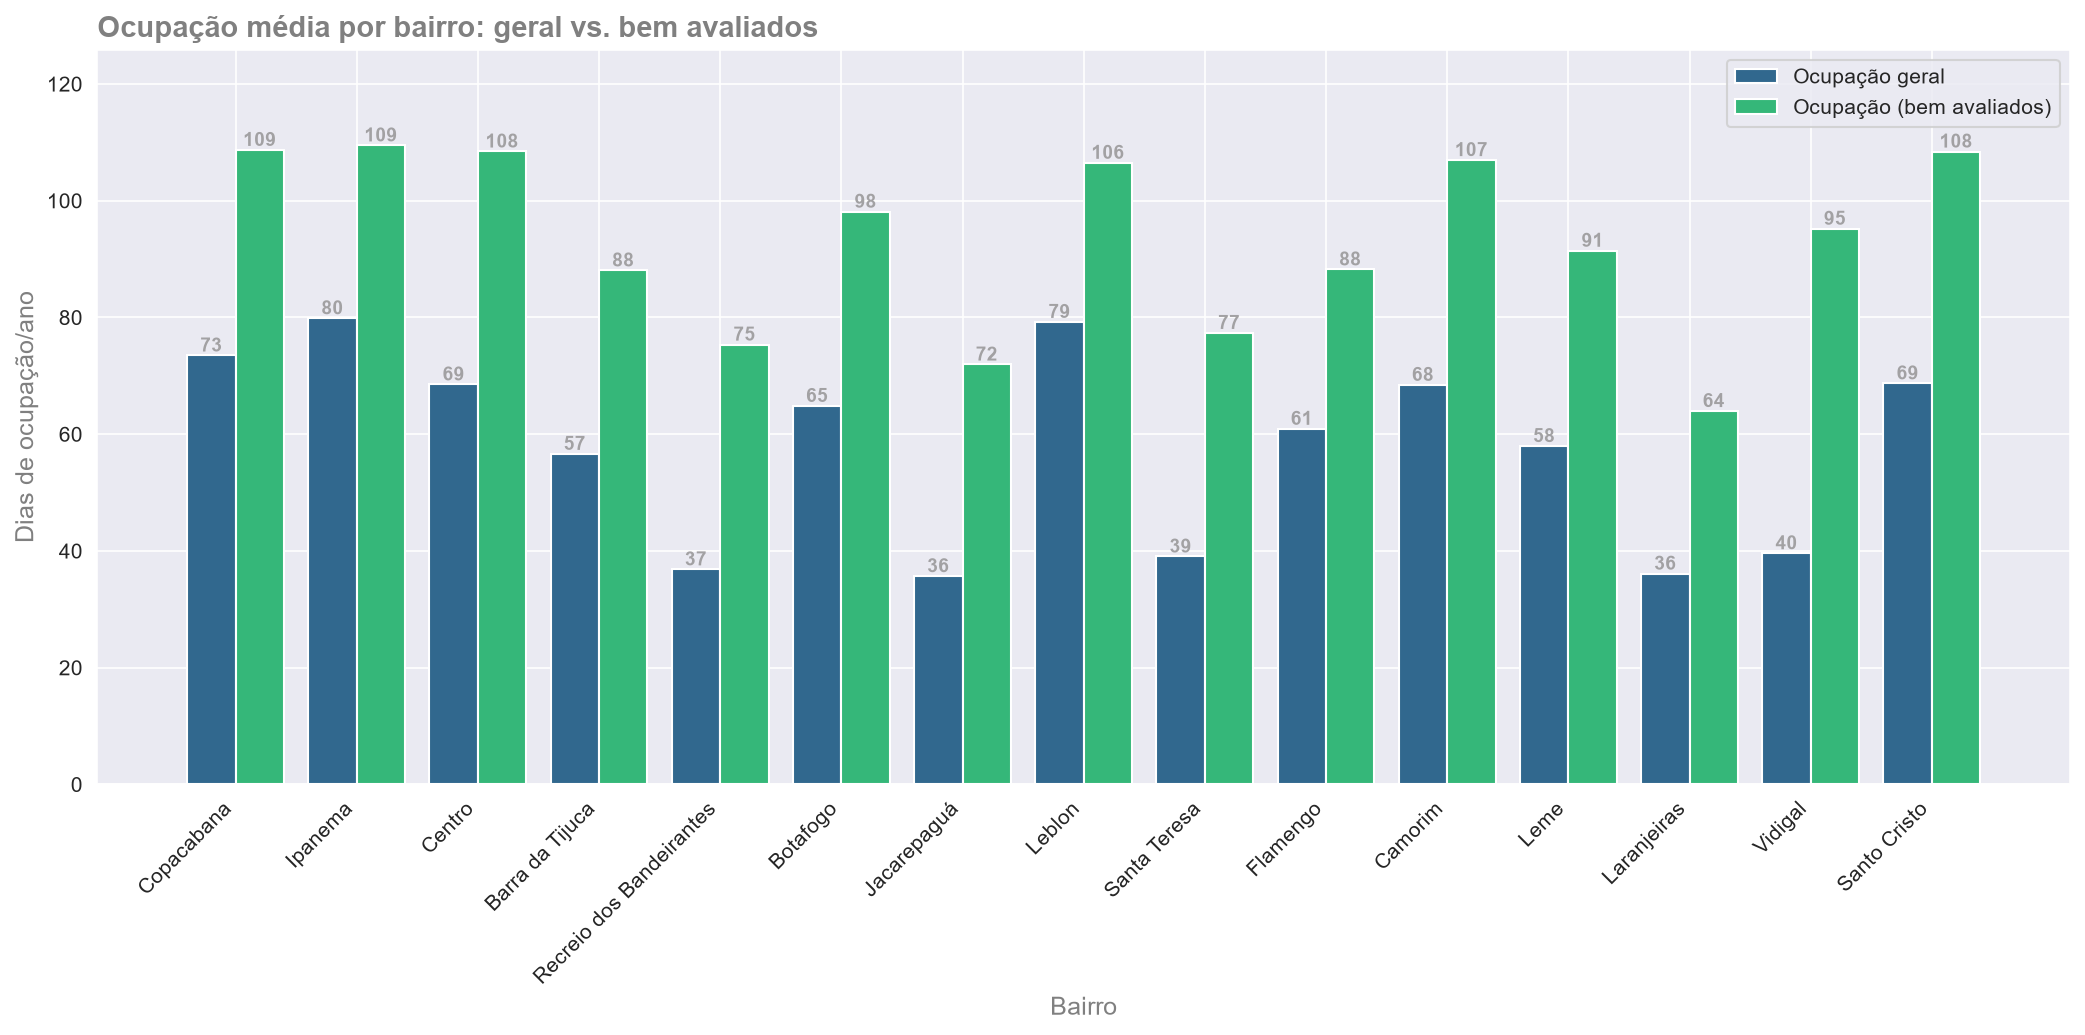

In [ ]:
# Gráfico

sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

bairros = resultado.index.tolist()
ocupacao_geral = resultado['ocupacao_media'].values
ocupacao_avaliados = resultado_top_avaliados['ocupacao_media'].values

x = np.arange(len(bairros))
largura = 0.4

barras1 = ax.bar(x - largura/2, ocupacao_geral, largura, label='Ocupação geral', color='#31688e')
barras2 = ax.bar(x + largura/2, ocupacao_avaliados, largura, label='Ocupação (bem avaliados)', color='#35b779')

for barras in [barras1, barras2]:
    for i in barras.patches:
        ax.annotate(f'{i.get_height():.0f}',
                    xy=(i.get_x() + i.get_width() / 2, i.get_height()),
                    color="#A2A1A3",
                    fontweight="semibold",
                    fontsize=9,
                    ha="center",
                    va="bottom")

ax.set_xticks(x)
ax.set_xticklabels(bairros, rotation=45, ha='right')
ax.set_title("Ocupação média por bairro: geral vs. bem avaliados", color="grey",
             fontsize=14, fontweight="semibold", loc="left")
ax.set_xlabel("Bairro", color="grey", fontsize=12)
ax.set_ylabel("Dias de ocupação/ano", color="grey", fontsize=12)
ax.legend()
ax.set_ylim(0, max(ocupacao_avaliados) * 1.15)
plt.tight_layout()
plt.savefig("Ocupacao_bairros.jpeg")

O gráfico compara a ocupação média anual dos imóveis nos 15 bairros com maior volume de anúncios, contrastando a média geral com a média de imóveis bem avaliados (nota ≥4.5 e no mínimo 5 reviews). Em todos os bairros analisados, a ocupação dos imóveis bem avaliados foi consistentemente maior que a média geral, chegando a quase dobrar em alguns casos — como Jacarepaguá (36 → 72 dias), Laranjeiras (36 → 64 dias) e Vidigal (40 → 95 dias). O padrão sugere que a reputação do anúncio (nota e volume de reviews) tem forte associação com a ocupação real, e esse efeito parece ainda mais relevante em bairros que, no geral, apresentam ocupação mais baixa — indicando que qualidade percebida pode compensar, ao menos parcialmente, uma localização menos procurada.

#### 3.4.2 - Qual é o "Efeito preço" dentro do "efeito avaliação"?

Será que os imóveis bem avaliados também são mais baratos que a média do bairro? Se forem, parte do ganho de ocupação pode ser preço, não reputação

In [76]:
comparacao_preco = dados.groupby('neighbourhood_cleansed').agg(
    preco_medio_geral=('price', 'mean')
).reindex(top15_bairros)

preco_bem_avaliados = dados[filtro].groupby('neighbourhood_cleansed').agg(
    preco_medio_avaliados=('price', 'mean')
).reindex(top15_bairros)

comparacao_preco['preco_medio_avaliados'] = preco_bem_avaliados['preco_medio_avaliados']
print(comparacao_preco.round(1))

                          preco_medio_geral  preco_medio_avaliados
neighbourhood_cleansed                                            
Copacabana                            584.5                  520.2
Ipanema                               845.4                  797.6
Centro                                332.2                  287.5
Barra da Tijuca                       749.7                  658.1
Recreio dos Bandeirantes              599.1                  528.5
Botafogo                              493.8                  429.5
Jacarepaguá                           660.2                  446.1
Leblon                                907.9                  866.3
Santa Teresa                          428.2                  365.0
Flamengo                              515.6                  440.3
Camorim                               421.9                  339.7
Leme                                  627.2                  556.9
Laranjeiras                           555.6                  4

O padrão é consistente: bem avaliados são mais baratos, não mais caros

A comparação de preços mostra que imóveis bem avaliados tendem a praticar preços mais baixos que a média do bairro. Isso sugere que parte do ganho de ocupação observado nos imóveis bem avaliados pode ser explicado por uma combinação de preço competitivo e boa reputação, e não pela reputação isoladamente. A investigação causal mais precisa (isolando o efeito de cada variável) fica reservada para a etapa de correlação/modelagem no notebook de análise preditiva.

#### 3.4.3 - Existe uma faixa de preço que maximiza ocupação?

In [77]:
dados['faixa_preco'] = pd.cut(dados['price'], bins=[0, 200, 400, 600, 900, 1500, 3000])
dados.groupby('faixa_preco')['estimated_occupancy_l365d'].mean()

faixa_preco
(0, 200]        68.491675
(200, 400]      72.681035
(400, 600]      62.054656
(600, 900]      51.087196
(900, 1500]     38.276371
(1500, 3000]    26.221757
Name: estimated_occupancy_l365d, dtype: float64

A ocupação não cai de forma linear com o preço — ela sobe até a faixa de R$200-400 (o pico, 72,7 dias) e só depois começa a cair de forma constante e acentuada. Isso sugere que preços muito baixos (abaixo de R$200) não são necessariamente a melhor estratégia — o "ponto ótimo" de ocupação fica um pouco acima do mínimo. E o mais notável: de R$400 a R$3.000, a queda é praticamente monotônica e forte — imóveis acima de R$1.500 ocupam menos da metade dos dias que os da faixa "sweet spot".

#### 3.4.4 - "Entire home/apt" ocupa mais que "Private room"?

In [78]:
dados.groupby('room_type')['estimated_occupancy_l365d'].mean().sort_values(ascending=False)

room_type
Entire home/apt    67.174587
Private room       31.134250
Shared room        21.733333
Hotel room         18.260870
Name: estimated_occupancy_l365d, dtype: float64

Imóveis inteiros ocupam mais que o dobro de dias que quartos privados, e mais que o triplo de quartos compartilhados. Isso é coerente com o perfil de demanda do Rio (turismo de lazer, família, grupos) — hóspedes parecem preferir fortemente privacidade completa. Vale mencionar isso como um fator relevante para quem for usar essa análise para orientar decisão de investimento (ex: "vale mais a pena comprar/alugar um studio inteiro do que oferecer quartos").

#### 3.4.5 - "Número de reviews" como proxy de maturidade do anúncio

vimos que ocupação sobe com nota alta — mas será que sobe simplesmente com mais tempo de mercado (mais reviews acumuladas), independente da nota?

In [79]:
dados['faixa_reviews'] = pd.cut(dados['number_of_reviews'], bins=[-1, 0, 5, 20, 50, 1000])
dados.groupby('faixa_reviews')['estimated_occupancy_l365d'].mean()

faixa_reviews
(-1, 0]         0.000000
(0, 5]          9.813625
(5, 20]        44.002551
(20, 50]      104.823184
(50, 1000]    158.431850
Name: estimated_occupancy_l365d, dtype: float64

#### 3.4.6 - Relação entre número de amenities e ocupação

In [97]:
dados[['numero_amenities', 'estimated_occupancy_l365d']].corr()

,numero_amenities,estimated_occupancy_l365d
numero_amenities,1.00000,0.33729
estimated_occupancy_l365d,0.33729,1.00000


correlação fraca


#### 3.4.6 - Resumo e Insights sobre ocupação e vacância

A análise exploratória da ocupação estimada (estimated_occupancy_l365d) revelou padrões relevantes ao cruzá-la com localização, avaliação, preço, tipo de imóvel e volume de reviews.

Ocupação geral do mercado
A ocupação média do mercado é de aproximadamente 60 dias/ano (16,5%), com vacância média de cerca de 305 dias/ano (83,5%) — padrão típico de locação por temporada, marcado por alta rotatividade de poucos imóveis versus baixa atividade da maioria.

Localização (top 15 bairros)
Bairros de maior volume de anúncios (Copacabana, Ipanema, Leblon, Centro) concentram também as maiores ocupações médias, enquanto bairros mais afastados do eixo turístico tradicional (Jacarepaguá, Laranjeiras, Recreio, Santa Teresa, Vidigal) apresentam ocupação bem mais baixa no geral.

Efeito da avaliação
Ao filtrar por imóveis bem avaliados (nota ≥4,5 e no mínimo 5 reviews), a ocupação média aumenta de forma consistente em todos os 15 bairros analisados, chegando a quase dobrar nos bairros de desempenho mais fraco (ex.: Jacarepaguá: 36 → 72 dias; Vidigal: 40 → 95 dias). Uma investigação complementar mostrou que os imóveis bem avaliados também praticam preços médios mais baixos que a média do bairro — sugerindo que o ganho de ocupação observado provavelmente resulta da combinação entre boa reputação e preço competitivo, não da reputação isoladamente.

Faixa de preço
A relação entre preço e ocupação não é linear: a ocupação atinge seu pico na faixa de R$200–400/diária (72,7 dias em média) e cai de forma constante e acentuada a partir daí, chegando a menos da metade nas faixas acima de R$1.500. Isso indica um "ponto ótimo" de precificação, em vez de uma relação simples de "quanto mais barato, melhor".

Tipo de imóvel
Imóveis do tipo Entire home/apt (imóvel inteiro) ocupam, em média, mais que o dobro dos dias de Private room e mais que o triplo de Shared room/Hotel room, indicando forte preferência dos hóspedes por privacidade completa.

Volume de reviews (leitura com cautela)
Existe uma relação muito forte entre número de reviews e ocupação (de 0 dias para imóveis sem review até 158 dias para imóveis com mais de 50 reviews). No entanto, essa relação provavelmente envolve causalidade invertida ou circular: mais ocupação ao longo do tempo tende a gerar mais reviews acumuladas, e não necessariamente o contrário. Por isso, esse indicador deve ser interpretado como um sinal de maturidade/desempenho histórico do anúncio, e não como uma alavanca direta que o anfitrião pode ajustar para aumentar ocupação — diferente de preço e tipo de imóvel, que são decisões que o anfitrião controla diretamente.

### 3.5 - Tratamento das variáveis categóricas/texto

entender a cardinalidade de cada categórica, para escolher a estratégia certa (one-hot direto, agrupamento antes do one-hot, etc.)

In [80]:
for col in ["room_type", "property_type", "neighbourhood_cleansed"]:
    print(f"{col}: {dados[col].nunique()} valores únicos")
    print(dados[col].value_counts().head(10))
    print("-" * 40)

room_type: 4 valores únicos
room_type
Entire home/apt    33502
Private room        7419
Shared room          570
Hotel room            23
Name: count, dtype: int64
----------------------------------------
property_type: 79 valores únicos
property_type
Entire rental unit                   28211
Private room in rental unit           4382
Entire home                           1740
Entire condo                          1515
Private room in home                  1388
Entire loft                            788
Entire serviced apartment              632
Room in hotel                          460
Private room in bed and breakfast      405
Private room in condo                  301
Name: count, dtype: int64
----------------------------------------
neighbourhood_cleansed: 154 valores únicos
neighbourhood_cleansed
Copacabana                  13109
Ipanema                      3276
Centro                       3004
Barra da Tijuca              2943
Recreio dos Bandeirantes     2164
Botafogo       

room_type — 4 categorias, sem problema

Distribuição bem concentrada (Entire home/apt domina), mas todas as categorias têm volume razoável, exceto Hotel room (23 registros — bem raro, mas não crítico). One-hot direto

### 3.4.1 - Dummies em "room_type"

In [81]:
dados = pd.get_dummies(dados, columns=["room_type"], drop_first=True)

property_type — 79 categorias, mas concentração forte no topo

Se você somar as top 10 categorias, elas cobrem cerca de 96% do dataset (39.822 de 41.514). Isso significa que as outras ~69 categorias somam só ~4% dos dados, espalhadas — candidatas claras a agrupar em "Other"

### 3.4.2 - Dummies em "property_type"

In [82]:
contagem_prop = dados['property_type'].value_counts()
top_10_prop = contagem_prop.head(10).index
dados['property_type'] = dados['property_type'].where(dados['property_type'].isin(top_10_prop), 'Other')

# Conferir resultado
print(dados['property_type'].value_counts())

property_type
Entire rental unit                   28211
Private room in rental unit           4382
Entire home                           1740
Other                                 1692
Entire condo                          1515
Private room in home                  1388
Entire loft                            788
Entire serviced apartment              632
Room in hotel                          460
Private room in bed and breakfast      405
Private room in condo                  301
Name: count, dtype: int64


In [83]:
dados = pd.get_dummies(dados, columns=["property_type"], drop_first=True)

neighbourhood_cleansed — 154 bairros, concentração bem menor

Aqui é diferente: as top 10 cobrem só ~77% dos dados (31.977 de 41.514), sobrando 23% espalhados pelos outros 144 bairros. Isso significa que "Other" ficaria com peso relevante (quase 1 em cada 4 imóveis),

Limite por frequência mínima (mais flexível que fixar em 10)

### 3.4.3 - Dummies em "neighbourhood_cleansed"

In [84]:
contagem_bairro = dados['neighbourhood_cleansed'].value_counts()
bairros_manter = contagem_bairro[contagem_bairro >= 200].index  # ajuste o limiar
print(f"Bairros mantidos: {len(bairros_manter)}")
dados['neighbourhood_cleansed'] = dados['neighbourhood_cleansed'].where(
    dados['neighbourhood_cleansed'].isin(bairros_manter), 'Other')

Bairros mantidos: 22


In [85]:
# Aplicar o agrupamento de bairros
dados['neighbourhood_cleansed'] = dados['neighbourhood_cleansed'].where(
    dados['neighbourhood_cleansed'].isin(bairros_manter), 'Other')

print(dados['neighbourhood_cleansed'].value_counts())

neighbourhood_cleansed
Copacabana                  13109
Other                        4322
Ipanema                      3276
Centro                       3004
Barra da Tijuca              2943
Recreio dos Bandeirantes     2164
Botafogo                     1779
Jacarepaguá                  1651
Leblon                       1620
Santa Teresa                 1546
Flamengo                      885
Camorim                       817
Leme                          793
Laranjeiras                   508
Vidigal                       437
Santo Cristo                  437
São Conrado                   435
Tijuca                        397
Catete                        388
Glória                        360
Lagoa                         225
Barra de Guaratiba            217
Campo Grande                  201
Name: count, dtype: int64


In [86]:
print(dados.columns.tolist())

['hosts_time_as_user_months', 'hosts_time_as_host_months', 'host_listings_count', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d', 'review_scores_rating', 'calculated_host_listings_count', 'vacancia_dias', 'faixa_preco', 'faixa_reviews', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'property_type_Entire home', 'property_type_Entire loft', 'property_type_Entire rental unit', 'property_type_Entire serviced apartment', 'property_type_Other', 'property_type_Private room in bed and breakfast', 'property_type_Private room in condo', 'property_type_Private room in home', 'property_type_Private room in rental unit', 'property_type_Room in hotel']


In [87]:
dados.columns

Index(['hosts_time_as_user_months', 'hosts_time_as_host_months',
       'host_listings_count', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d',
       'review_scores_rating', 'calculated_host_listings_count',
       'vacancia_dias', 'faixa_preco', 'faixa_reviews', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'property_type_Entire home', 'property_type_Entire loft',
       'property_type_Entire rental unit',
       'property_type_Entire serviced apartment', 'property_type_Other',
       'property_type_Private room in bed and breakfast',
       'property_type_Private room in condo',
       'property_type_Private room in home',
       'property_type_Private room in rental unit',
       'property_type_Room in hotel'],
      dtype='str')

### 3.4.1 - Amenites

In [88]:
dados['amenities'].iloc[0]

'["Kitchen", "TV", "Smoking allowed", "Dedicated workspace", "BBQ grill"]'

In [89]:
import ast

dados['amenities'] = dados['amenities'].apply(ast.literal_eval)  # transforma string em lista de fato
dados['numero_amenities'] = dados['amenities'].apply(len)
dados = dados.drop(columns=['amenities'])

In [90]:
dados[['numero_amenities']].describe()
print(dados.shape)

(41514, 35)


In [91]:
print(dados.columns.tolist())

['hosts_time_as_user_months', 'hosts_time_as_host_months', 'host_listings_count', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d', 'review_scores_rating', 'calculated_host_listings_count', 'vacancia_dias', 'faixa_preco', 'faixa_reviews', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'property_type_Entire home', 'property_type_Entire loft', 'property_type_Entire rental unit', 'property_type_Entire serviced apartment', 'property_type_Other', 'property_type_Private room in bed and breakfast', 'property_type_Private room in condo', 'property_type_Private room in home', 'property_type_Private room in rental unit', 'property_type_Room in hotel', 'numero_amenities']


In [92]:
dados['numero_amenities'].describe()

count    41514.000000
mean        25.528352
std         14.710251
min          0.000000
25%         12.000000
50%         25.000000
75%         36.000000
max        115.000000
Name: numero_amenities, dtype: float64

In [93]:
dados.isnull().sum().sort_values(ascending=False)

hosts_time_as_user_months                          0
hosts_time_as_host_months                          0
host_listings_count                                0
neighbourhood_cleansed                             0
latitude                                           0
longitude                                          0
accommodates                                       0
bathrooms                                          0
bedrooms                                           0
beds                                               0
price                                              0
minimum_nights                                     0
maximum_nights                                     0
availability_365                                   0
number_of_reviews                                  0
estimated_occupancy_l365d                          0
review_scores_rating                               0
calculated_host_listings_count                     0
vacancia_dias                                 

## 4 - Normalizando a coluna price

os próprios histogramas já mostraram — distribuição bem assimétrica à direita (cauda longa até R$3.000, concentração forte entre R$200-700). Regressão linear assume (idealmente) que os resíduos sejam normalmente distribuídos, e transformar o alvo com log costuma:

Aproximar a distribuição de uma normal
Reduzir a influência desproporcional dos valores mais altos
Muitas vezes melhorar bastante o ajuste do modelo em dados de preço/imóveis (é praticamente padrão em modelos desse tipo)

In [94]:
dados['log_price'] = np.log1p(dados['price'])  # log1p evita problema se houver algum 0

## 5 - Salvando o DF

In [95]:
dados.columns

Index(['hosts_time_as_user_months', 'hosts_time_as_host_months',
       'host_listings_count', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'availability_365',
       'number_of_reviews', 'estimated_occupancy_l365d',
       'review_scores_rating', 'calculated_host_listings_count',
       'vacancia_dias', 'faixa_preco', 'faixa_reviews', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'property_type_Entire home', 'property_type_Entire loft',
       'property_type_Entire rental unit',
       'property_type_Entire serviced apartment', 'property_type_Other',
       'property_type_Private room in bed and breakfast',
       'property_type_Private room in condo',
       'property_type_Private room in home',
       'property_type_Private room in rental unit',
       'property_type_Room in hotel', 'numero_amenities', 'log_price'],
      dtype=

In [96]:
dados.to_csv('./processed/rio_airbnb_tratado.csv', index=False)